# Module 1d - Bring Your Own Table: upload, pick two columns, get a model

The most common place people get stuck is not the model, it is **getting their own data in**. This module removes that wall. You click a button, choose a file **from your computer**, tell it **which columns are the inputs** and **which one column is the output**, and it trains an ensemble model and shows you the result. No chemistry assumptions, no manual featurizing: any table works.

It is deliberately robust. It reads `.csv`, `.tsv`, `.txt`, and Excel (`.xlsx`, `.xls`); it retries encodings (UTF-8, GBK for Chinese Excel exports, Latin-1) and sniffs the delimiter; numeric columns pass through, text columns become one-hot features, high-cardinality id or free-text columns are dropped with a note, missing values are filled, and it decides regression vs classification for you.

You only ever edit **two lines** (Section 2). Everything else runs as is.

- **Model:** Random Forest and XGBoost, plus their committee average. Ensembles are the reliable default for tabular data, and both are easy to swap.
- **Runs with no upload too:** if you do not pick a file, it falls back to a shipped example table so the notebook always produces a result.

## 0. Setup

In [1]:
# Colab setup: fetch the repo and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_1_tabular_ML"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

ready in /Users/ruiding/mac_python_folder/NRT_training_materials_RD_June2026/module_1_tabular_ML


In [2]:
import sys, subprocess
# scikit-learn + xgboost + shap do the modeling; openpyxl lets pandas read .xlsx. Install on Colab (no-op locally).
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "scikit-learn", "xgboost", "shap", "openpyxl"])

## 1. Upload your table

Run the cell and **click the button**, then choose a file from your computer. Cancel the dialog to use the shipped example instead. The reader is forgiving: CSV, TSV, or Excel; comma / tab / semicolon separators; UTF-8, GBK, or Latin-1 encodings.

In [3]:
import io, sys, pandas as pd

def read_table(name, data):
    """Read bytes from any common table file, trying encodings and delimiters."""
    if name.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(io.BytesIO(data))
    for enc in ("utf-8", "gbk", "latin-1"):
        try:
            return pd.read_csv(io.BytesIO(data), sep=None, engine="python", encoding=enc)
        except Exception:
            continue
    return pd.read_csv(io.BytesIO(data))          # last resort

df = None
if "google.colab" in sys.modules:
    from google.colab import files
    print("Click the button and choose a LOCAL .csv / .tsv / .xlsx file.")
    print("(Cancel the dialog to use the shipped example table instead.)")
    up = files.upload()
    if up:
        nm = list(up)[0]
        df = read_table(nm, up[nm]); print("loaded YOUR file:", nm)
if df is None:
    with open("data/example_table.csv", "rb") as f:
        df = read_table("example_table.csv", f.read())
    print("using the shipped example table (real OER catalyst recipes).")

df.columns = [str(c).strip() for c in df.columns]   # tidy header whitespace
print("\nrows x columns:", df.shape)
print("columns:", list(df.columns))
df.head()

using the shipped example table (real OER catalyst recipes).

rows x columns: (1246, 10)
columns: ['primary_metal', 'secondary_metal', 'primary_pct', 'secondary_pct', 'hydrothermal_temp_C', 'annealing_temp_C', 'annealing_time_min', 'catalyst_loading_mg_cm2', 'proton_conc_M', 'overpotential_mV']


,primary_metal,secondary_metal,primary_pct,secondary_pct,hydrothermal_temp_C,annealing_temp_C,annealing_time_min,catalyst_loading_mg_cm2,proton_conc_M,overpotential_mV
0,Co,NaN,100.000000,0.000000,150,400,60.0,0.9020,1.0,422
1,Co,NaN,99.337748,0.662252,150,400,60.0,0.8877,1.0,396
2,Ru,NaN,83.333333,16.666667,0,500,60.0,0.2290,1.0,191
3,Ru,NaN,75.000000,25.000000,0,500,60.0,0.2290,1.0,221
4,Ru,NaN,87.500000,12.500000,0,500,60.0,0.2290,1.0,217


## 2. Pick your columns  ·  EDIT HERE

This is the only cell you change. Set the one column to predict, and the columns to predict from.

In [4]:
# ==================  EDIT THESE TWO LINES  ==================
OUTPUT_COLUMN = df.columns[-1]      # the ONE column to predict. default = the last column. e.g. "yield"
INPUT_COLUMNS = None                # columns to predict FROM. None = every other column. e.g. ["temp", "time", "metal"]
# ===========================================================

target   = OUTPUT_COLUMN
features = list(INPUT_COLUMNS) if INPUT_COLUMNS else [c for c in df.columns if c != target]
assert target in df.columns, f"OUTPUT_COLUMN '{target}' is not a column. Columns are: {list(df.columns)}"
print("predict      :", target)
print("from columns :", features)

predict      : overpotential_mV
from columns : ['primary_metal', 'secondary_metal', 'primary_pct', 'secondary_pct', 'hydrothermal_temp_C', 'annealing_temp_C', 'annealing_time_min', 'catalyst_loading_mg_cm2', 'proton_conc_M']


## 3. Turn the table into numbers  (automatic)

Numeric columns pass through. Text columns with a small number of distinct values become one-hot features. High-cardinality text (ids, names, free text) is dropped with a note. Missing values are filled, rows with no target are removed, and the task (regression vs classification) is decided from the output column.

In [5]:
import numpy as np, pandas as pd
MAX_CAT = 20        # a text column with more distinct values than this is treated as an id and dropped

Xraw = df[features].copy(); y = df[target]
keep = y.notna(); Xraw, y = Xraw[keep], y[keep]                      # drop rows with no target

num     = Xraw.select_dtypes(include="number").columns.tolist()
cat_all = [c for c in Xraw.columns if c not in num]
cat     = [c for c in cat_all if Xraw[c].nunique(dropna=True) <= MAX_CAT]
dropped = [c for c in cat_all if c not in cat]

X = pd.get_dummies(Xraw[num + cat], columns=cat, dummy_na=False)
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True)).fillna(0.0)

is_num = pd.api.types.is_numeric_dtype(y)
TASK = "regression" if (is_num and y.nunique() > 10) else "classification"

print(f"task decided : {TASK}")
print(f"features used: {X.shape[1]} columns  ({len(num)} numeric + one-hot of {cat if cat else 'none'})")
if dropped: print(f"dropped      : {dropped}  (too many distinct values, looks like an id or free text)")
print(f"samples      : {len(X)}")

task decided : regression
features used: 18 columns  (7 numeric + one-hot of ['primary_metal', 'secondary_metal'])
samples      : 1246


## 4. Train the ensemble  (Random Forest + XGBoost)

An 80/20 split, two tree ensembles, and their committee average. Regression is scored by R2 and MAE; classification by accuracy and macro-F1.

In [6]:
from sklearn.model_selection import train_test_split
RND = 0

if TASK == "regression":
    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor
    from sklearn.metrics import r2_score, mean_absolute_error
    Xtr, Xte, ytr, yte = train_test_split(X, y.astype(float), test_size=0.2, random_state=RND)
    models = {"RandomForest": RandomForestRegressor(n_estimators=400, random_state=RND, n_jobs=-1),
              "XGBoost":      XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                           subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1)}
    preds = {}
    for n, m in models.items():
        m.fit(Xtr, ytr); preds[n] = m.predict(Xte)
        print(f"{n:13s} R2={r2_score(yte, preds[n]):.3f}   MAE={mean_absolute_error(yte, preds[n]):.3g}")
    ens = np.mean(list(preds.values()), axis=0)
    print(f"{'Committee':13s} R2={r2_score(yte, ens):.3f}   MAE={mean_absolute_error(yte, ens):.3g}")
else:
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.metrics import accuracy_score, f1_score
    ycat = y.astype("category"); classes = list(ycat.cat.categories); ycode = ycat.cat.codes
    Xtr, Xte, ytr, yte = train_test_split(X, ycode, test_size=0.2, random_state=RND, stratify=ycode)
    models = {"RandomForest": RandomForestClassifier(n_estimators=400, random_state=RND, n_jobs=-1),
              "XGBoost":      XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=5,
                                            subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1)}
    preds = {}
    for n, m in models.items():
        m.fit(Xtr, ytr); preds[n] = m.predict(Xte)
        acc = accuracy_score(yte, preds[n]); f1 = f1_score(yte, preds[n], average="macro")
        print(f"{n:13s} accuracy={acc:.3f}   macro-F1={f1:.3f}")
    print(f"classes: {classes}")

RandomForest  R2=0.484   MAE=41.3


XGBoost       R2=0.525   MAE=40.1
Committee     R2=0.519   MAE=40.4


## 5. See the result

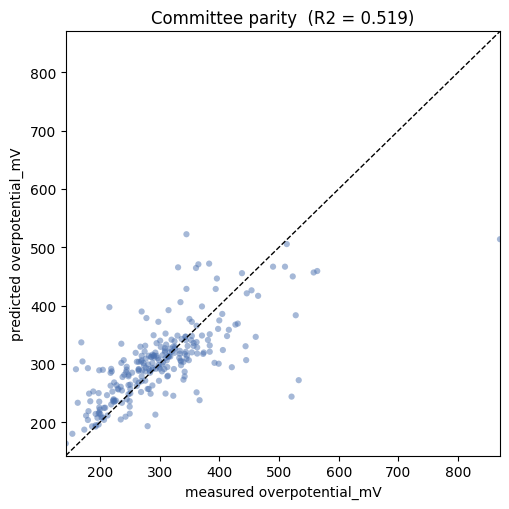

In [7]:
import matplotlib.pyplot as plt
os.makedirs("figures", exist_ok=True)

if TASK == "regression":
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    lims = [min(yte.min(), ens.min()), max(yte.max(), ens.max())]
    ax.scatter(yte, ens, s=20, alpha=0.5, color="#4C72B0", edgecolor="none")
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xlim=lims, ylim=lims, xlabel=f"measured {target}", ylabel=f"predicted {target}",
           title=f"Committee parity  (R2 = {r2_score(yte, ens):.3f})")
    fig.tight_layout(); fig.savefig("figures/1d_result.png", dpi=140); plt.show()
else:
    from sklearn.metrics import confusion_matrix
    m = models["RandomForest"]; cm = confusion_matrix(yte, preds["RandomForest"])
    fig, ax = plt.subplots(figsize=(5.6, 5.0))
    im = ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
           xticklabels=classes, yticklabels=classes,
           xlabel="predicted", ylabel="actual", title="Confusion matrix (RandomForest)")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.tight_layout(); fig.savefig("figures/1d_result.png", dpi=140); plt.show()

## 6. Which columns matter

Feature importance from the model. When SHAP is available it is used (it shows direction and magnitude); otherwise the model's built-in importances are shown. Either way, this is what to report and what to probe next.

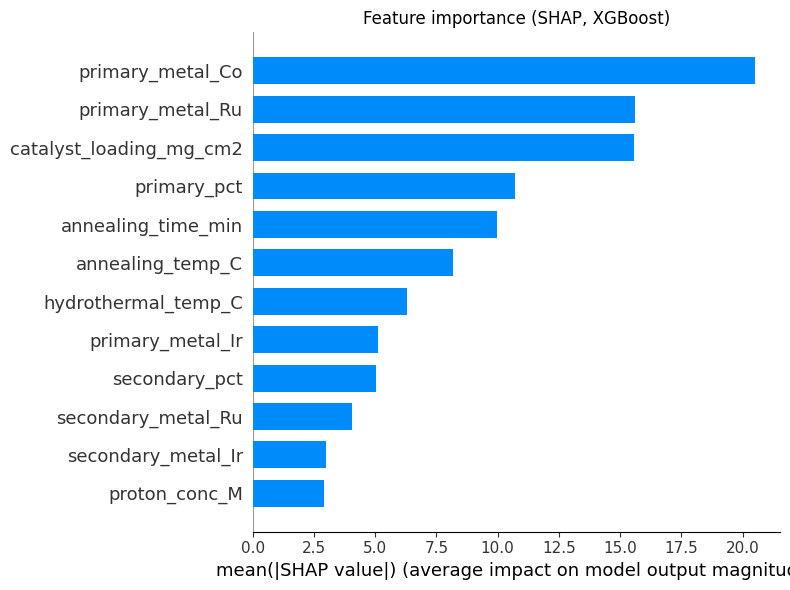

In [8]:
import matplotlib.pyplot as plt
xgb = models["XGBoost"]
Xs = Xte.sample(min(300, len(Xte)), random_state=RND)
try:
    import shap
    sv = shap.TreeExplainer(xgb).shap_values(Xs)
    shap.summary_plot(sv, Xs, plot_type="bar", max_display=12, show=False)
    plt.gcf().set_size_inches(8, 6); plt.title("Feature importance (SHAP, XGBoost)")
    plt.tight_layout(); plt.savefig("figures/1d_importance.png", dpi=140, bbox_inches="tight"); plt.show()
except Exception as e:
    imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values().tail(12)
    fig, ax = plt.subplots(figsize=(8, 6)); ax.barh(imp.index, imp.values, color="#55A868")
    ax.set_title("Feature importance (XGBoost built-in)"); fig.tight_layout()
    fig.savefig("figures/1d_importance.png", dpi=140, bbox_inches="tight"); plt.show()
    print("(SHAP unavailable, used built-in importances:", e, ")")

## 7. Make it yours

- **Your data:** re-run Section 1, click the button, pick your file.
- **Your columns:** change the two lines in Section 2. Set `OUTPUT_COLUMN` to what you want to predict, and either leave `INPUT_COLUMNS = None` to use everything else or list the exact columns.
- **Everything else is automatic:** numeric vs text handling, missing values, regression vs classification, and the ensemble.
- **Swap the model** in Section 4 if you like; the rest of the notebook does not care which regressor or classifier you use.

This is the fastest path from a spreadsheet to a first model and an honest importance plot. When you outgrow it (element-aware features, uncertainty, active learning), Modules 1a to 1c show the next steps.